In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
path_to_data = "/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/nuGun_pT_0_50_reco_0.h5"

df = pd.read_hdf(path_to_data, key="df") 
print(df)



          event                    collection  \
0             0  InnerTrackerBarrelCollection   
1             0  InnerTrackerBarrelCollection   
2             0  InnerTrackerBarrelCollection   
3             0  InnerTrackerBarrelCollection   
4             0  InnerTrackerBarrelCollection   
...         ...                           ...   
26580638      0        VertexEndcapCollection   
26580639      0        VertexEndcapCollection   
26580640      0        VertexEndcapCollection   
26580641      0        VertexEndcapCollection   
26580642      0        VertexEndcapCollection   

                                                     object  \
0         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
1         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
2         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
3         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
4         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
...                              

In [ ]:
NUM_R0WS = 26_580_643

In [40]:
collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]

for col in collections:
    df_col = df[df["collection"] == col]
    print(col, len(df_col))


    df_col_selected = df_col[["Edep", "x", "y", "z", "t"]].to_numpy()

    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/{col}_SimTrackerHit.npy", df_col_selected)

InnerTrackerBarrelCollection 6639439
InnerTrackerEndcapCollection 2360215
OuterTrackerBarrelCollection 6787500
OuterTrackerEndcapCollection 2825825
VertexBarrelCollection 2641857
VertexEndcapCollection 5325807


# Make geometry map

In [65]:
NUM_EVENTS_PER_COL = 500_000
geometry_map = {}

from tqdm import tqdm

for col in collections:

    df_col = df[df["collection"] == col]
    
    for i in tqdm(range(NUM_EVENTS_PER_COL)):
    
        event = df_col.iloc[i]
    
        key = (
            event["collection"],
            event["system"],
            event["side"],
            event["layer"],
            event["module"],
            event["sensor"],
            event["cellid0"],
            event["x"],
            event["y"],
            event["z"],
        )
    
        geometry_map[key] = True


with open("geometry_map.txt", "w", encoding="utf-8") as f:
    f.write("Valid CellID combinations:\n")
    for cell_tuple in sorted(geometry_map):
        f.write(str(cell_tuple) + "\n")

print(f"Saved {len(geometry_map)} unique hits to geometry_map.txt")



100%|██████████| 500000/500000 [00:42<00:00, 11735.18it/s]


Saved 3000000 unique hits to geometry_map.txt


In [66]:
from collections import defaultdict
from scipy.spatial import cKDTree


geom_map = defaultdict(list)  # collection -> (x,y,z,cellid0)

i = 0
with open("geometry_map.txt", "r", encoding="utf-8") as f:
    for line in f:

        if line.startswith("("):
            tup = eval(line)

            x = float(tup[7])
            y = float(tup[8])
            z = float(tup[9])
            col_name = tup[0]
            cellid0 = int(tup[6])
            layer = int(tup[3])

            geom_map[col_name].append((x, y, z, cellid0, layer))

print(
    f"Loaded geometry map with {sum(len(v) for v in geom_map.values())} hits across {len(geom_map)} collections"
)


# Build KDTree for each collection
tree_map = {}
cellid_map = {}
pos_map = {}


for col, hits in geom_map.items():


    coords = np.array([(x, y, z) for x, y, z, _, _ in hits])

    tree_map[col] = cKDTree(coords)

    cellid_map[col] = np.array([(cid, layer) for _, _, _, cid, layer in hits], dtype=np.int64)
    pos_map[col] = coords

Loaded geometry map with 3000000 hits across 6 collections


In [67]:
col_hits_per_layer = {col:{} for col in collections}



def find_closest_cellid(col_name, x, y, z):
    """Return CellID0 of closest geometry hit."""
    dist, idx = tree_map[col_name].query([x, y, z])

    returned_pos = pos_map[col_name][idx]
    return returned_pos, cellid_map[col_name][idx]


dists = []
for i in tqdm(range(0, 26580643, 1000)):


    event = df.iloc[i]
    layer_truth = event["layer"]
    x_truth, y_truth, z_truth = event["x"], event["y"], event["z"]
 

    returned_pos, cellid = find_closest_cellid(event["collection"], event["x"], event["y"], event["z"])
    dist = np.sqrt((returned_pos[0] - x_truth)**2 + (returned_pos[1] - y_truth)**2 + (returned_pos[2] - z_truth)**2)

    returned_layer = cellid[1]
    if returned_layer != layer_truth:
        print('ERROR', event["collection"], returned_layer, layer_truth, dist)


    try:
        col_hits_per_layer[event["collection"]][returned_layer] += 1
    except KeyError:
        col_hits_per_layer[event["collection"]][returned_layer] = 0
    
        
    dists.append(dist)

    
    

 99%|█████████▊| 26201/26581 [00:04<00:00, 5820.04it/s]

ERROR VertexEndcapCollection 4 5 4.196515207466004
ERROR VertexEndcapCollection 7 6 4.135882250354425


100%|██████████| 26581/26581 [00:04<00:00, 5847.66it/s]


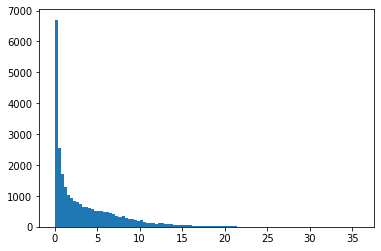

In [68]:
plt.figure()
plt.hist(dists, bins = 100)
plt.show()

In [69]:
print(col_hits_per_layer)

{'InnerTrackerBarrelCollection': {2: 2108, 1: 2022, 0: 2507}, 'InnerTrackerEndcapCollection': {1: 570, 6: 112, 0: 757, 5: 136, 2: 387, 4: 161, 3: 230}, 'OuterTrackerBarrelCollection': {2: 2023, 0: 2566, 1: 2196}, 'OuterTrackerEndcapCollection': {2: 645, 3: 549, 0: 832, 1: 795}, 'VertexBarrelCollection': {6: 301, 1: 732, 4: 293, 0: 945, 2: 366}, 'VertexEndcapCollection': {0: 959, 5: 620, 1: 991, 6: 371, 7: 337, 3: 720, 4: 587, 2: 733}}


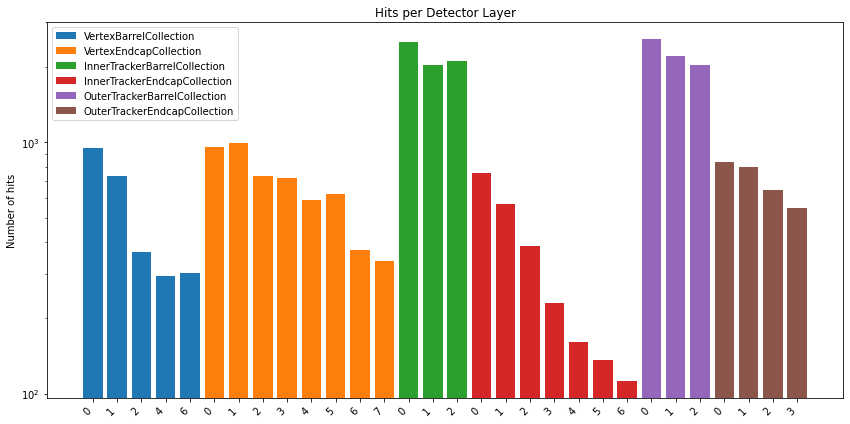

In [70]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]

# Prepare x positions
width = 0.1  # width of each bar
x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection

fig, ax = plt.subplots(figsize=(12, 6))

# Keep track of total x positions
x_pos = 0
x_labels = []
x_ticks = []

for coll in collections_order:
    layers = sorted(col_hits_per_layer[coll].keys())  # sort layers numerically
    counts = [col_hits_per_layer[coll][l] for l in layers]

    # compute positions for this collection
    positions = x_pos + np.arange(len(layers))
    ax.bar(positions, counts, width=0.8, label=coll)
    
    # collect labels and ticks
    x_labels.extend([f"{l}" for l in layers])
    x_ticks.extend(positions)
    
    # update x_pos for next collection to avoid overlap
    x_pos = positions[-1] + 1  # add gap between collections

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel("Number of hits")
ax.set_title("Hits per Detector Layer")
ax.legend()
plt.tight_layout()
plt.yscale("log")
plt.show()